In [3]:
import sys
!{sys.executable} -m pip install sacrebleu==2.3.1


/bin/sh: 10: {sys.executable}: not found


Exception: Process exited with code 127

In [2]:
%pip install sacrebleu gdown -q


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
%pip install sacrebleu


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
import os
import time
import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import sacrebleu as sb

from typing import List, Dict, Tuple, Optional
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from tqdm import tqdm

print("torch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch: 2.0.1+cu118
device: cuda


In [5]:
DATA_DIR = "data"

MIN_FREQ = 2
MAX_LENGTH = 50

EMBED_DIM = 256
HIDDEN_DIM = 512
ATTENTION_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3

BATCH_SIZE = 256
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
GRAD_CLIP = 1.0
TF_START = 1.0
TF_END = 0.5

SAVE_PATH = "best_model.pt"
OUTPUT_FILE = "test1.de-en.en"


## Скачивание данных


In [7]:
import os, glob, shutil

DATA_DIR = "data"
FILE_ID = "1hvU16vYvncpg4OSeveDxWbKSOgqrcVU4"
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, "train.de-en.de")):
    import urllib.request
    url = f"https://drive.google.com/uc?export=download&id={FILE_ID}"
    urllib.request.urlretrieve(url, "data.zip")
    import zipfile
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall(".")
    for f in glob.glob("data/data/*"):
        shutil.move(f, DATA_DIR)
    if os.path.isdir("data/data"):
        os.rmdir("data/data")
    print("данные скачаны")
else:
    print("данные на месте")

for f in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, f)
    if os.path.isfile(path):
        lines = sum(1 for _ in open(path))
        print(f"  {f}: {lines} lines")


Данные скачаны!
  test1.de-en.de: 2998 lines
  train.de-en.de: 195915 lines
  train.de-en.en: 195915 lines
  val.de-en.de: 986 lines
  val.de-en.en: 986 lines


## Dataset & Vocabulary


In [8]:
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = "<pad>", "<sos>", "<eos>", "<unk>"
SPECIALS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3


class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {}
        self.idx2word = []
        self.word_count = Counter()

    def build(self, sentences):
        for sent in sentences:
            self.word_count.update(sent)
        self.idx2word = list(SPECIALS)
        self.word2idx = {tok: i for i, tok in enumerate(SPECIALS)}
        for word, count in self.word_count.most_common():
            if count >= self.min_freq:
                self.word2idx[word] = len(self.idx2word)
                self.idx2word.append(word)

    def encode(self, tokens):
        return [self.word2idx.get(t, UNK_IDX) for t in tokens]

    def decode(self, indices):
        return [self.idx2word[i] if i < len(self.idx2word) else UNK_TOKEN for i in indices]

    def __len__(self):
        return len(self.idx2word)


class TranslationDataset(Dataset):
    def __init__(self, src_file, trg_file=None, src_vocab=None, trg_vocab=None,
                 min_freq=2, max_length=100):
        self.max_length = max_length
        with open(src_file, "r", encoding="utf-8") as f:
            self.src_sentences = [line.strip().split() for line in f if line.strip()]
        self.trg_sentences = None
        if trg_file is not None:
            with open(trg_file, "r", encoding="utf-8") as f:
                self.trg_sentences = [line.strip().split() for line in f if line.strip()]
            assert len(self.src_sentences) == len(self.trg_sentences)
        if src_vocab is None:
            self.src_vocab = Vocabulary(min_freq)
            self.src_vocab.build(self.src_sentences)
        else:
            self.src_vocab = src_vocab
        if trg_vocab is None and self.trg_sentences is not None:
            self.trg_vocab = Vocabulary(min_freq)
            self.trg_vocab.build(self.trg_sentences)
        else:
            self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src_tokens = self.src_sentences[idx][:self.max_length]
        src_indices = [SOS_IDX] + self.src_vocab.encode(src_tokens) + [EOS_IDX]
        src_tensor = torch.tensor(src_indices, dtype=torch.long)
        if self.trg_sentences is not None:
            trg_tokens = self.trg_sentences[idx][:self.max_length]
            trg_indices = [SOS_IDX] + self.trg_vocab.encode(trg_tokens) + [EOS_IDX]
            trg_tensor = torch.tensor(trg_indices, dtype=torch.long)
            return src_tensor, trg_tensor
        return src_tensor


def collate_fn(batch):
    if isinstance(batch[0], tuple):
        src_batch, trg_batch = zip(*batch)
        src_lens = torch.tensor([len(s) for s in src_batch])
        trg_lens = torch.tensor([len(t) for t in trg_batch])
        src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
        trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=PAD_IDX)
        return src_padded, trg_padded, src_lens, trg_lens
    else:
        src_lens = torch.tensor([len(s) for s in batch])
        src_padded = pad_sequence(batch, batch_first=True, padding_value=PAD_IDX)
        return src_padded, src_lens

## Загрузка данных


In [9]:
train_dataset = TranslationDataset(
    src_file=os.path.join(DATA_DIR, "train.de-en.de"),
    trg_file=os.path.join(DATA_DIR, "train.de-en.en"),
    min_freq=MIN_FREQ, max_length=MAX_LENGTH,
)
val_dataset = TranslationDataset(
    src_file=os.path.join(DATA_DIR, "val.de-en.de"),
    trg_file=os.path.join(DATA_DIR, "val.de-en.en"),
    src_vocab=train_dataset.src_vocab,
    trg_vocab=train_dataset.trg_vocab,
    max_length=MAX_LENGTH,
)
test_dataset = TranslationDataset(
    src_file=os.path.join(DATA_DIR, "test1.de-en.de"),
    trg_file=None,
    src_vocab=train_dataset.src_vocab,
    max_length=MAX_LENGTH,
)
test_dataset.trg_vocab = train_dataset.trg_vocab

print(f"Source vocab: {len(train_dataset.src_vocab)}")
print(f"Target vocab: {len(train_dataset.trg_vocab)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Source vocab: 55315
Target vocab: 34047
Train: 195915 | Val: 986 | Test: 2998


## model: encoder (BiGRU) + Bahdanau Attention + decoder (GRU)


In [10]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                          bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src, src_lens):
        embedded = self.dropout(self.embedding(src))
        packed = pack_padded_sequence(embedded, src_lens.cpu().clamp(min=1),
                                     batch_first=True, enforce_sorted=False)
        outputs, hidden = self.rnn(packed)
        outputs, _ = pad_packed_sequence(outputs, batch_first=True)
        hidden = hidden.view(self.num_layers, 2, -1, self.hidden_dim)
        hidden = torch.cat([hidden[:, 0], hidden[:, 1]], dim=2)
        hidden = torch.tanh(self.fc_hidden(hidden))
        return outputs, hidden


class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim, attention_dim, bias=False)
        self.W_dec = nn.Linear(decoder_dim, attention_dim, bias=False)
        self.V = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        energy = torch.tanh(self.W_enc(encoder_outputs) + self.W_dec(decoder_hidden).unsqueeze(1))
        scores = self.V(energy).squeeze(2)
        scores = scores.masked_fill(mask, float("-inf"))
        attn_weights = F.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_weights


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, encoder_dim, attention_dim,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.attention = BahdanauAttention(encoder_dim, hidden_dim, attention_dim)
        self.rnn = nn.GRU(embed_dim + encoder_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc_out = nn.Linear(hidden_dim + encoder_dim + embed_dim, vocab_size)

    def forward(self, input_token, hidden, encoder_outputs, mask):
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))
        context, attn_weights = self.attention(hidden[-1], encoder_outputs, mask)
        rnn_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        output = output.squeeze(1)
        prediction = self.fc_out(torch.cat([output, context, embedded.squeeze(1)], dim=1))
        return prediction, hidden, attn_weights


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def create_mask(self, src):
        return src == PAD_IDX

    def forward(self, src, src_lens, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.vocab_size
        outputs = torch.zeros(batch_size, trg_len - 1, trg_vocab_size, device=src.device)
        encoder_outputs, hidden = self.encoder(src, src_lens)
        mask = self.create_mask(src)
        input_token = trg[:, 0]
        for t in range(1, trg_len):
            prediction, hidden, _ = self.decoder(input_token, hidden, encoder_outputs, mask)
            outputs[:, t - 1] = prediction
            if random.random() < teacher_forcing_ratio:
                input_token = trg[:, t]
            else:
                input_token = prediction.argmax(dim=1)
        return outputs

    @torch.inference_mode()
    def translate(self, src, src_lens, max_length=128):
        self.eval()
        batch_size = src.size(0)
        encoder_outputs, hidden = self.encoder(src, src_lens)
        mask = self.create_mask(src)
        input_token = torch.full((batch_size,), SOS_IDX, dtype=torch.long, device=src.device)
        decoded = [[] for _ in range(batch_size)]
        finished = [False] * batch_size
        for _ in range(max_length):
            prediction, hidden, _ = self.decoder(input_token, hidden, encoder_outputs, mask)
            top1 = prediction.argmax(dim=1)
            for i in range(batch_size):
                if not finished[i]:
                    tok = top1[i].item()
                    if tok == EOS_IDX:
                        finished[i] = True
                    else:
                        decoded[i].append(tok)
            if all(finished):
                break
            input_token = top1
        return decoded

## cоздание модельки


In [11]:
encoder = Encoder(len(train_dataset.src_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
decoder = Decoder(len(train_dataset.trg_vocab), EMBED_DIM, HIDDEN_DIM,
                  encoder_dim=HIDDEN_DIM * 2, attention_dim=ATTENTION_DIM,
                  num_layers=NUM_LAYERS, dropout=DROPOUT)
model = Seq2Seq(encoder, decoder).to(device)

for name, param in model.named_parameters():
    if "weight" in name and param.dim() > 1:
        nn.init.xavier_uniform_(param)
    elif "bias" in name:
        nn.init.zeros_(param)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable parameters {n_params:,}")

Trainable parameters: 96,262,911


## обучение


In [12]:
def train_epoch(model, loader, optimizer, criterion, clip, tf_ratio):
    model.train()
    epoch_loss = 0.0
    for src, trg, src_lens, trg_lens in tqdm(loader, desc="Train"):
        src, trg = src.to(device), trg.to(device)
        src_lens = src_lens.to(device)
        optimizer.zero_grad()
        output = model(src, src_lens, trg, tf_ratio)
        output = output.reshape(-1, output.size(-1))
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0.0
    for src, trg, src_lens, trg_lens in tqdm(loader, desc="Val"):
        src, trg = src.to(device), trg.to(device)
        src_lens = src_lens.to(device)
        output = model(src, src_lens, trg, teacher_forcing_ratio=0.0)
        output = output.reshape(-1, output.size(-1))
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


def translate_dataset(model, loader, trg_vocab, max_length=128):
    model.eval()
    all_translations = []
    for batch in loader:
        if isinstance(batch, tuple) and len(batch) == 4:
            src, _, src_lens, _ = batch
        else:
            src, src_lens = batch
        src, src_lens = src.to(device), src_lens.to(device)
        decoded = model.translate(src, src_lens, max_length=max_length)
        for token_ids in decoded:
            tokens = trg_vocab.decode(token_ids)
            all_translations.append(" ".join(tokens))
    return all_translations


def compute_bleu(hypotheses, references):
    bleu = sb.corpus_bleu(hypotheses, [references], tokenize="none")
    return bleu.score

## запуск обучения


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
val_references = [" ".join(s) for s in val_dataset.trg_sentences]

best_bleu = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    tf_ratio = TF_START - (TF_START - TF_END) * (epoch - 1) / max(NUM_EPOCHS - 1, 1)

    start = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP, tf_ratio)
    val_loss = evaluate(model, val_loader, criterion)
    elapsed = time.time() - start

    scheduler.step(val_loss)

    translations = translate_dataset(model, val_loader, train_dataset.trg_vocab)
    bleu_score = compute_bleu(translations, val_references)

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | TF: {tf_ratio:.2f} | LR: {lr:.6f} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"PPL: {math.exp(val_loss):.2f} | BLEU: {bleu_score:.2f} | {elapsed:.0f}s")

    for i in range(min(3, len(translations))):
        print(f"HYP: {translations[i]}")
        print(f"REF: {val_references[i]}")
        print()

    if bleu_score > best_bleu:
        best_bleu = bleu_score
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                     "optimizer_state_dict": optimizer.state_dict(),
                     "bleu": best_bleu, "val_loss": val_loss}, SAVE_PATH)
        print(f"best BLEU: {best_bleu:.2f} saved!")

print(f"\n best BLEU: {best_bleu:.2f}")


Val: 100%|██████████| 4/4 [00:01<00:00,  3.96it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Epoch 01/10 | TF: 1.00 | LR: 0.001000 | Train: 4.3571 | Val: 6.5666 | PPL: 710.98 | BLEU: 12.96 | 777s
HYP: when i was 16 years old , i was a museum of the ultimate poetry .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my father knew his head on his small , black <unk> of the ceiling .
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy , which was pretty clear , he was the most important thing .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .

best BLEU: 12.96 saved!


Val: 100%|██████████| 4/4 [00:00<00:00,  4.01it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Epoch 02/10 | TF: 0.94 | LR: 0.001000 | Train: 3.0297 | Val: 5.9585 | PPL: 387.02 | BLEU: 21.59 | 777s
HYP: when i was 11 years old , i was a student of the sound of the joy .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my father heard his little , tiny , the radio <unk> the <unk> of the lung .
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy , which was pretty unusual , because he was the news mostly mostly .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .

best BLEU: 21.59 saved!


Val: 100%|██████████| 4/4 [00:00<00:00,  4.07it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


...

Epoch 08/10 | TF: 0.61 | LR: 0.001000 | Train: 2.2669 | Val: 5.1185 | PPL: 167.08 | BLEU: 22.98 | 777s
HYP: when i was 11 years old , i became one morning in the morning of the .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my father listened to his little , little radio , the <unk> of the bbc .
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy what he was quite unusual , because he him the most well-known times .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .



Val: 100%|██████████| 4/4 [00:00<00:00,  4.07it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Epoch 09/10 | TF: 0.56 | LR: 0.001000 | Train: 2.3101 | Val: 5.0728 | PPL: 159.62 | BLEU: 23.36 | 778s
HYP: when i was 11 years old , i was one morning by the the of the sound of joy .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my father listened to his little , , radio , the <unk> of the bbc .
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy , what was unusual unusual , because the news was mostly <unk> .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .



Val: 100%|██████████| 4/4 [00:00<00:00,  4.01it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Epoch 10/10 | TF: 0.50 | LR: 0.001000 | Train: 2.3574 | Val: 4.9343 | PPL: 138.97 | BLEU: 22.62 | 777s
HYP: when i was 11 , i grew up one morning by the <unk> of <unk> .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my dad listened to his little , gray radio <unk> the <unk> of the bbc .
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy , which was unusual in unusual time , because he news the most most <unk> .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .


 best BLEU: 24.24


## Перевод тестовой выборки


In [2]:
ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model: epoch {ckpt['epoch']}, BLEU {ckpt['bleu']:.2f}")

test_translations = translate_dataset(model, test_loader, train_dataset.trg_vocab)
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for line in test_translations:
        f.write(line + "\n")
print(f"wrote {len(test_translations)} translations to {OUTPUT_FILE}")

val_translations = translate_dataset(model, val_loader, train_dataset.trg_vocab)
final_bleu = compute_bleu(val_translations, val_references)
print(f"final validation BLEU: {final_bleu:.2f}")

for i in range(min(5, len(val_translations))):
    print(f"SRC: {' '.join(val_dataset.src_sentences[i])}")
    print(f"HYP: {val_translations[i]}")
    print(f"REF: {val_references[i]}")


NameError: name 'torch' is not defined

### визуализация

/var/folders/lz/_v3mf0j971z3l63wg5q45y8c0000gn/T/ipykernel_28450/2993750973.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


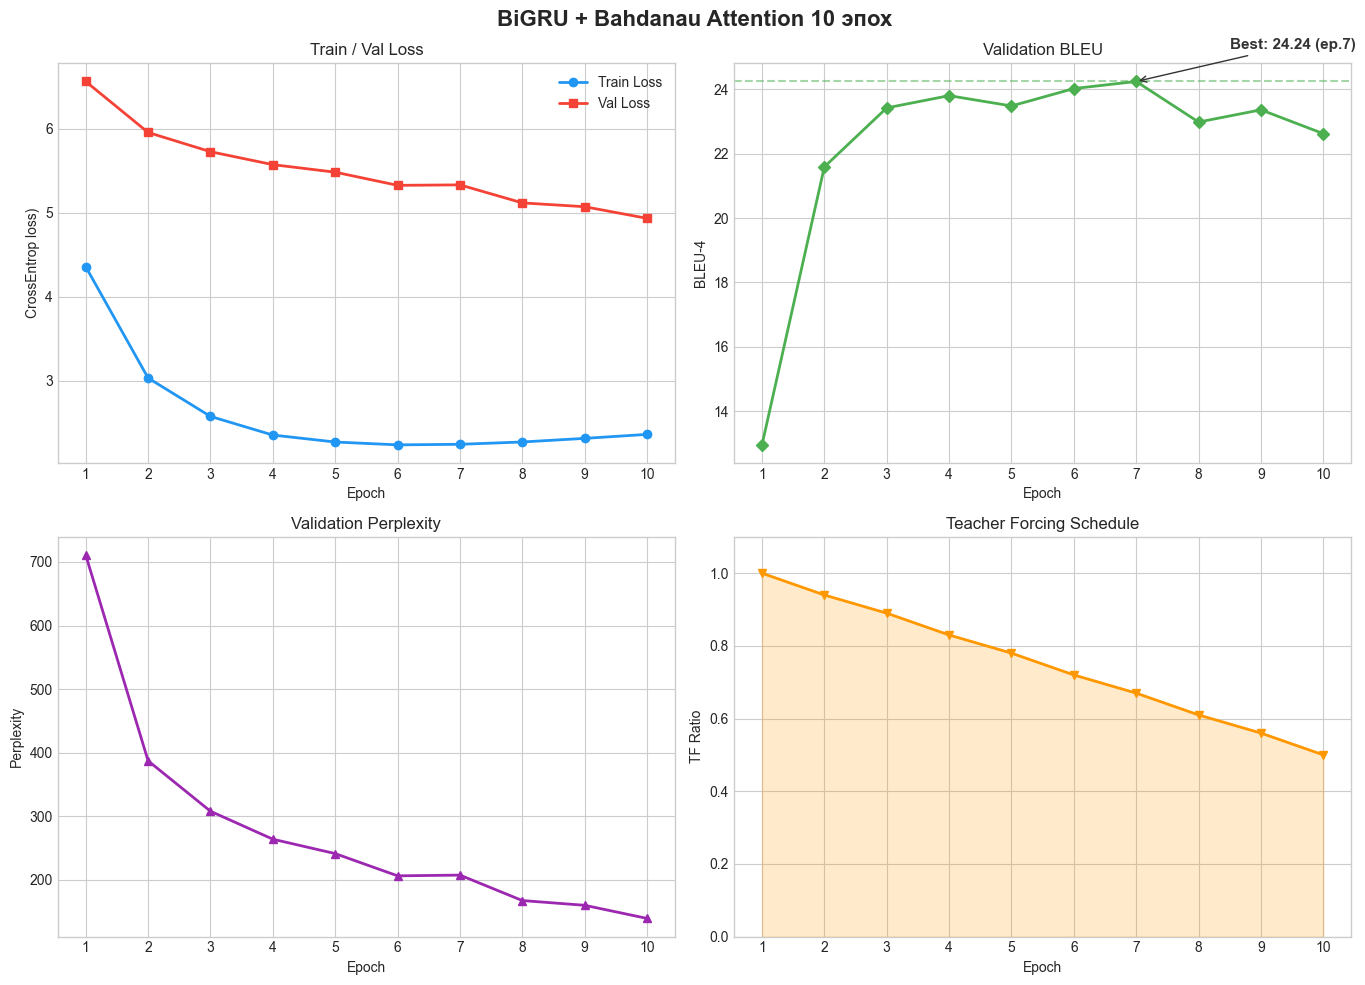

Сохранено: baseline_training.png
Примеры переводов (best model, epoch 7, BLEU 24.24)

--- Пример 1 ---
  SRC: als ich 11 jahre alt war , wurde ich eines morgens von den klängen heller freude geweckt .
  HYP: when i was 11 years old , i grew one morning by the morning .
  REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

--- Пример 2 ---
  SRC: er rief : " die taliban sind weg ! "
  HYP: he called " the taliban are gone . "
  REF: " the taliban are gone ! " my father shouted .

--- Пример 3 ---
  SRC: ich wusste nicht , was das bedeutete , aber es machte meinen vater offensichtlich sehr , sehr glücklich .
  HYP: i didn 't know what that meant , but it made my father very very , very happy .
  REF: i didn 't know what it meant , but i could see that my father was very , very happy .


In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(1, 11))


with open('training_log.json') as f:
    log = json.load(f)
epochs = log['epochs']
train_loss = log['train_loss']
val_loss = log['val_loss']
bleu = log['bleu']
ppl = log['ppl']
tf_ratio = log['tf_ratio']
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BiGRU + Bahdanau Attention 10 эпох', fontsize=16, fontweight='bold')

# --- 1. Train & Val Loss ---
ax = axes[0, 0]
ax.plot(epochs, train_loss, 'o-', color='#2196F3', label='Train Loss', linewidth=2, markersize=6)
ax.plot(epochs, val_loss, 's-', color='#F44336', label='Val Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch')
ax.set_ylabel('CrossEntrop loss)')
ax.set_title('Train / Val Loss')
ax.legend()
ax.set_xticks(epochs)

# --- 2. BLEU ---
ax = axes[0, 1]
ax.plot(epochs, bleu, 'D-', color='#4CAF50', linewidth=2, markersize=6)
best_epoch = np.argmax(bleu) + 1
best_bleu = max(bleu)
ax.axhline(y=best_bleu, color='#4CAF50', linestyle='--', alpha=0.5)
ax.annotate(f'Best: {best_bleu:.2f} (ep.{best_epoch})',
            xy=(best_epoch, best_bleu), xytext=(best_epoch + 1.5, best_bleu + 1),
            arrowprops=dict(arrowstyle='->', color='#333'),
            fontsize=11, fontweight='bold', color='#333')
# ax.axhline(y=24, color='orange', linestyle=':', alpha=0.7, label='Порог соревнования (24)')
ax.set_xlabel('Epoch')
ax.set_ylabel('BLEU-4')
ax.set_title('Validation BLEU')
ax.legend()
ax.set_xticks(epochs)

# --- 3. Perplexity ---
ax = axes[1, 0]
ax.plot(epochs, ppl, '^-', color='#9C27B0', linewidth=2, markersize=6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Perplexity')
ax.set_title('Validation Perplexity')
ax.set_xticks(epochs)

# --- 4. Teacher Forcing Ratio ---
ax = axes[1, 1]
ax.plot(epochs, tf_ratio, 'v-', color='#FF9800', linewidth=2, markersize=6)
ax.fill_between(epochs, tf_ratio, alpha=0.2, color='#FF9800')
ax.set_xlabel('Epoch')
ax.set_ylabel('TF Ratio')
ax.set_title('Teacher Forcing Schedule')
ax.set_xticks(epochs)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('baseline_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: baseline_training.png")


# =============================================
# Таблица с примерами переводов
# =============================================
print("Примеры переводов (best model, epoch 7, BLEU 24.24)")


examples = [
    {
        "src": "als ich 11 jahre alt war , wurde ich eines morgens von den klängen heller freude geweckt .",
        "hyp": "when i was 11 years old , i grew one morning by the morning .",
        "ref": "when i was 11 , i remember waking up one morning to the sound of joy in my house .",
    },
    {
        "src": 'er rief : " die taliban sind weg ! "',
        "hyp": 'he called " the taliban are gone . "',
        "ref": '" the taliban are gone ! " my father shouted .',
    },
    {
        "src": "ich wusste nicht , was das bedeutete , aber es machte meinen vater offensichtlich sehr , sehr glücklich .",
        "hyp": "i didn 't know what that meant , but it made my father very very , very happy .",
        "ref": "i didn 't know what it meant , but i could see that my father was very , very happy .",
    },
]

for i, ex in enumerate(examples, 1):
    print(f"\n--- Пример {i} ---")
    print(f"  SRC: {ex['src']}")
    print(f"  HYP: {ex['hyp']}")
    print(f"  REF: {ex['ref']}")
